# 🩸 Diabetes Disease Prediction Model
### Training Notebook — generates `saved_models/diabetes_model.pkl`
**Algorithm:** Support Vector Machine (SVM) with linear kernel  
**Dataset:** PIMA Indians Diabetes Dataset (768 samples, 8 features)  
**Target:** `Outcome` — 0 = Not Diabetic, 1 = Diabetic

## 1. Install & Import Dependencies

In [2]:
pip install numpy pandas scikit-learn matplotlib seaborn

   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 262.6 kB/s eta 0:00:02
   -------- ------------------------------ 61.4/294.9 kB 363.1 kB/s eta 0:00:01
   --------------------- ---------------- 163.8/294.9 kB 756.6 kB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 1.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Install required libraries (run once)
# !pip install numpy pandas scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import svm
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## 2. Load & Explore the Dataset

In [5]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Place diabetes.csv in the same folder as this notebook
# OR update the path below
df = pd.read_csv('diabetes.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
# Basic statistics
print("Dataset Statistics:")
df.describe().round(2)

Dataset Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


Class Distribution (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64

  0 = Not Diabetic : 500 samples
  1 = Diabetic      : 268 samples


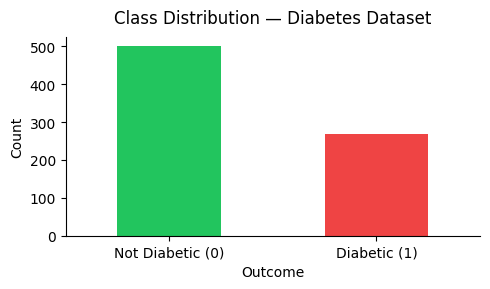

In [7]:
# Class distribution
print("Class Distribution (Outcome):")
print(df['Outcome'].value_counts())
print(f"\n  0 = Not Diabetic : {(df['Outcome']==0).sum()} samples")
print(f"  1 = Diabetic      : {(df['Outcome']==1).sum()} samples")

# Visualise class balance
fig, ax = plt.subplots(figsize=(5, 3))
df['Outcome'].value_counts().plot(kind='bar', ax=ax,
    color=['#22c55e', '#ef4444'], edgecolor='none')
ax.set_xticklabels(['Not Diabetic (0)', 'Diabetic (1)'], rotation=0)
ax.set_title('Class Distribution — Diabetes Dataset', fontsize=12, pad=10)
ax.set_ylabel('Count')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Check for Missing Values

In [8]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total missing values: 0


## 4. Feature Correlation Heatmap

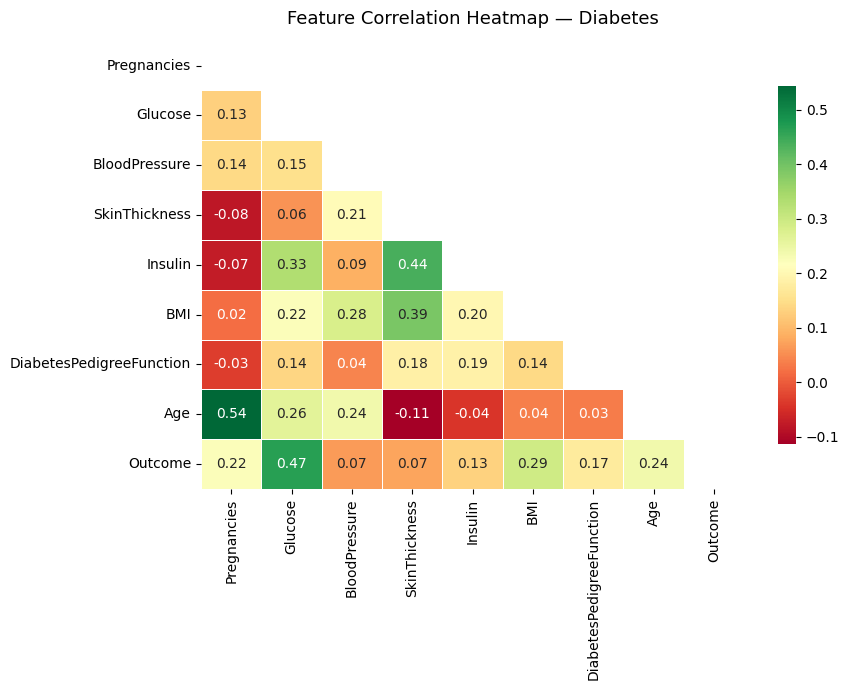

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap — Diabetes', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## 5. Prepare Features & Labels

In [10]:
# Separate features (X) and target (Y)
X = df.drop(columns=['Outcome'])
Y = df['Outcome']

print("Feature columns:", list(X.columns))
print("\nFeature matrix shape:", X.shape)
print("Label vector shape  :", Y.shape)

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Feature matrix shape: (768, 8)
Label vector shape  : (768,)


## 6. Train / Test Split

In [11]:
# 80% train, 20% test — stratified to preserve class balance
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=2
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nTrain class balance: {dict(Y_train.value_counts())}")
print(f"Test  class balance: {dict(Y_test.value_counts())}")

Training set : 614 samples
Test set     : 154 samples

Train class balance: {0: 400, 1: 214}
Test  class balance: {0: 100, 1: 54}


## 7. Train the SVM Model

In [12]:
# Support Vector Machine with linear kernel (same as original repo)
classifier = svm.SVC(kernel='linear', random_state=2)
classifier.fit(X_train, Y_train)

print("✅ Model training complete!")
print(f"   Model type : {type(classifier).__name__}")
print(f"   Kernel     : {classifier.kernel}")
print(f"   C (reg.)   : {classifier.C}")

✅ Model training complete!
   Model type : SVC
   Kernel     : linear
   C (reg.)   : 1.0


## 8. Model Evaluation

In [13]:
# ── Accuracy scores ───────────────────────────────────────────────────────────
train_pred = classifier.predict(X_train)
test_pred  = classifier.predict(X_test)

train_acc = accuracy_score(Y_train, train_pred)
test_acc  = accuracy_score(Y_test,  test_pred)

print("=" * 45)
print("        MODEL ACCURACY REPORT")
print("=" * 45)
print(f"  Training Accuracy : {train_acc*100:.2f}%")
print(f"  Test     Accuracy : {test_acc*100:.2f}%")
print("=" * 45)

        MODEL ACCURACY REPORT
  Training Accuracy : 78.34%
  Test     Accuracy : 77.27%


In [14]:
# ── Detailed classification report ───────────────────────────────────────────
print("\nClassification Report (Test Set):\n")
print(classification_report(Y_test, test_pred,
      target_names=['Not Diabetic', 'Diabetic']))


Classification Report (Test Set):

              precision    recall  f1-score   support

Not Diabetic       0.78      0.91      0.84       100
    Diabetic       0.76      0.52      0.62        54

    accuracy                           0.77       154
   macro avg       0.77      0.71      0.73       154
weighted avg       0.77      0.77      0.76       154



In [15]:
# ── 5-Fold Cross-Validation ───────────────────────────────────────────────────
cv_scores = cross_val_score(classifier, X, Y, cv=5, scoring='accuracy')
print(f"5-Fold CV Scores   : {[round(s*100,2) for s in cv_scores]}")
print(f"CV Mean Accuracy   : {cv_scores.mean()*100:.2f}%")
print(f"CV Std Deviation   : ±{cv_scores.std()*100:.2f}%")

5-Fold CV Scores   : [75.97, 75.32, 74.03, 81.05, 76.47]
CV Mean Accuracy   : 76.57%
CV Std Deviation   : ±2.38%


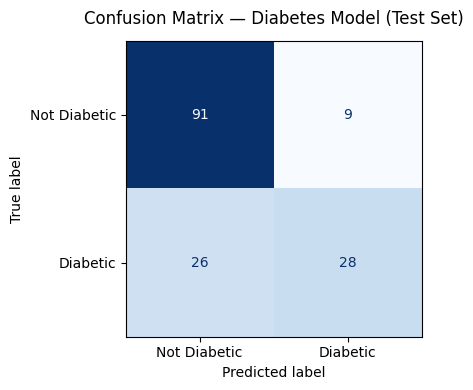


  True  Positives (Diabetic correctly identified)    : 28
  True  Negatives (Healthy correctly identified)     : 91
  False Positives (Healthy flagged as Diabetic)      : 9
  False Negatives (Diabetic missed by model)         : 26


In [16]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(Y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Diabetic', 'Diabetic'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Diabetes Model (Test Set)', pad=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n  True  Positives (Diabetic correctly identified)    : {tp}")
print(f"  True  Negatives (Healthy correctly identified)     : {tn}")
print(f"  False Positives (Healthy flagged as Diabetic)      : {fp}")
print(f"  False Negatives (Diabetic missed by model)         : {fn}")

## 9. Feature Importance (via SVM weights)

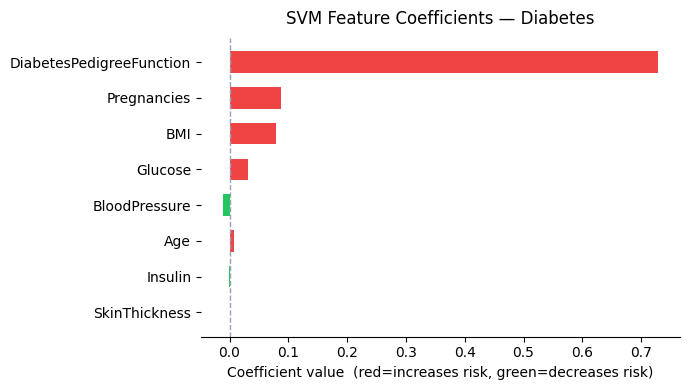

In [17]:
# Linear SVM exposes coefficients — magnitude = importance
feature_names = list(X.columns)
coefs = classifier.coef_[0]

importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Coefficient': coefs,
    'Abs_Coef'  : np.abs(coefs)
}).sort_values('Abs_Coef', ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#ef4444' if c > 0 else '#22c55e' for c in importance_df['Coefficient']]
ax.barh(importance_df['Feature'], importance_df['Coefficient'],
        color=colors, edgecolor='none', height=0.6)
ax.axvline(0, color='#94a3b8', linewidth=1, linestyle='--')
ax.set_title('SVM Feature Coefficients — Diabetes', fontsize=12, pad=10)
ax.set_xlabel('Coefficient value  (red=increases risk, green=decreases risk)')
ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout()
plt.show()

## 10. Sample Prediction

In [18]:
# Test with a known diabetic sample (from the original repo notebook)
# Pregnancies=5, Glucose=166, BloodPressure=72, SkinThickness=19,
# Insulin=175, BMI=25.8, DiabetesPedigreeFunction=0.587, Age=51
sample = np.array([[5, 166, 72, 19, 175, 25.8, 0.587, 51]])

result = classifier.predict(sample)
print("Sample input:", dict(zip(feature_names, sample[0])))
print(f"\nPrediction: {'🔴 DIABETIC' if result[0]==1 else '🟢 NOT DIABETIC'}")
print(f"Expected  : 🔴 DIABETIC  (confirmed from dataset)")

Sample input: {'Pregnancies': 5.0, 'Glucose': 166.0, 'BloodPressure': 72.0, 'SkinThickness': 19.0, 'Insulin': 175.0, 'BMI': 25.8, 'DiabetesPedigreeFunction': 0.587, 'Age': 51.0}

Prediction: 🔴 DIABETIC
Expected  : 🔴 DIABETIC  (confirmed from dataset)


## 11. Save Model as `.pkl`

In [19]:
# Create the saved_models directory if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

# Save the trained model
model_path = 'saved_models/diabetes_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(classifier, f)

# Verify round-trip load
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

verify_acc = accuracy_score(Y_test, loaded_model.predict(X_test))

print("=" * 45)
print("  ✅  MODEL SAVED SUCCESSFULLY")
print("=" * 45)
print(f"  File        : {model_path}")
print(f"  Size        : {os.path.getsize(model_path):,} bytes")
print(f"  Verify acc  : {verify_acc*100:.2f}%  (matches original ✓)")
print()
print("  → Place 'saved_models/diabetes_model.pkl'")
print("    inside your project's saved_models/ folder")
print("    then run:  streamlit run app.py")

  ✅  MODEL SAVED SUCCESSFULLY
  File        : saved_models/diabetes_model.pkl
  Size        : 27,669 bytes
  Verify acc  : 77.27%  (matches original ✓)

  → Place 'saved_models/diabetes_model.pkl'
    inside your project's saved_models/ folder
    then run:  streamlit run app.py
